# Fashion MNIST CNN Assignment
GSBS 545 — Advanced ML for Business Analytics

Build, ablate, and tune a CNN for Fashion MNIST. The structure: load + EDA, baseline CNN, four single-factor ablations on top of the baseline, Optuna tuning, then a single held-out test evaluation and a personal workflow.

Two design choices worth flagging:
- `X_test`, `y_test` from `fashion_mnist.load_data()` are sealed until the final cell. All tuning uses a validation split off the training data, so the test evaluation is honest.
- Ablations are cumulative — each experiment adds one factor to the previous best. This is the "change one factor at a time" pattern the assignment asks for, and it makes the contribution of each change easy to read.

## Setup

In [2]:
# Colab pre-installs everything except a recent Optuna integration module.
# If you hit an import error on the next cell, uncomment:
!pip install -q optuna

In [3]:
import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Fashion MNIST and explore

Keras ships Fashion MNIST. 60k train / 10k test, 28x28 grayscale, 10 balanced classes.

In [4]:
from tensorflow.keras.datasets import fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Train images: {X_train_full.shape}, labels: {y_train_full.shape}")
print(f"Test images:  {X_test.shape}, labels: {y_test.shape}")
print(f"Pixel range:  [{X_train_full.min()}, {X_train_full.max()}]")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images: (60000, 28, 28), labels: (60000,)
Test images:  (10000, 28, 28), labels: (10000,)
Pixel range:  [0, 255]


In [5]:
# Class distribution — Fashion MNIST is balanced, but verify.
counts = pd.Series(y_train_full).value_counts().sort_index()
counts.index = CLASS_NAMES
counts

,count
T-shirt/top,6000
Trouser,6000
Pullover,6000
Dress,6000
Coat,6000
Sandal,6000
Shirt,6000
Sneaker,6000
Bag,6000
Ankle boot,6000


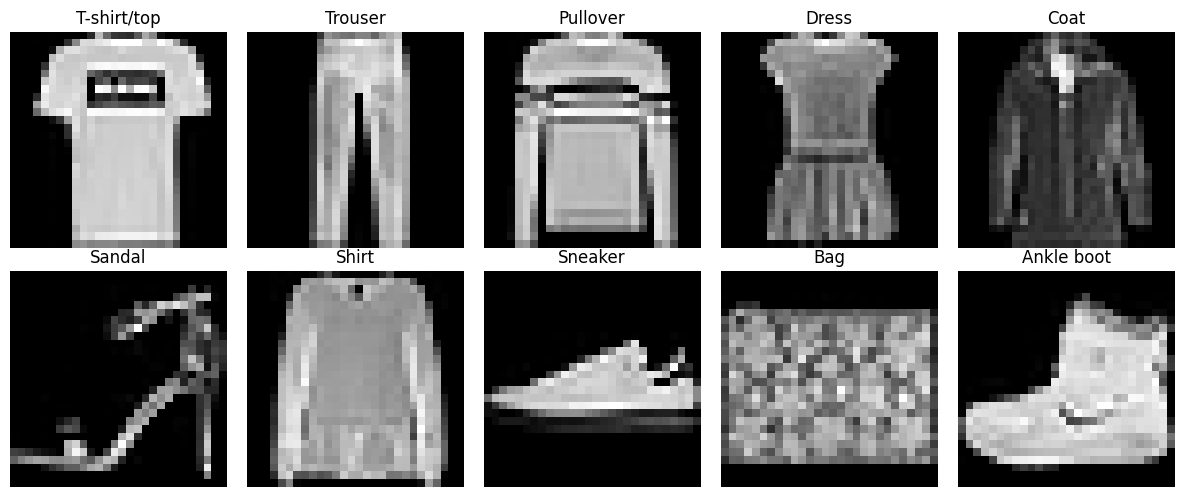

In [6]:
# One sample per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c, ax in enumerate(axes.flat):
    idx = np.where(y_train_full == c)[0][0]
    ax.imshow(X_train_full[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[c]); ax.axis("off")
plt.tight_layout(); plt.show()

## Preprocessing

Three things: add a channel dim so Conv2D is happy, scale pixels to [0, 1], and carve a validation split off the train set with stratification.

In [7]:
X_train_full = X_train_full.astype("float32").reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.astype("float32").reshape(-1, 28, 28, 1) / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, stratify=y_train_full, random_state=SEED
)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (54000, 28, 28, 1)  Val: (6000, 28, 28, 1)  Test: (10000, 28, 28, 1)


## Helper functions

In [8]:
def make_early_stop(patience=5):
    return keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )

def plot_history(history, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["loss"], label="train")
    ax[0].plot(history.history["val_loss"], label="val")
    ax[0].set_title(f"{title} — Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history.history["accuracy"], label="train")
    ax[1].plot(history.history["val_accuracy"], label="val")
    ax[1].set_title(f"{title} — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

# Experiment tracker
results = []

def log_run(name, model, history, val_acc, val_loss):
    train_acc = history.history["accuracy"][-1]
    results.append({
        "experiment": name,
        "params": model.count_params(),
        "epochs_run": len(history.history["loss"]),
        "train_acc": round(train_acc, 4),
        "best_val_acc": round(max(history.history["val_accuracy"]), 4),
        "final_val_acc": round(val_acc, 4),
        "val_loss": round(val_loss, 4),
        "overfit_gap": round(train_acc - val_acc, 4),
    })

## Baseline CNN

Single Conv2D block + Dense head. Intentionally minimal so subsequent ablations have headroom to demonstrate effects.

In [9]:
def build_baseline():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="baseline_cnn")
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(1e-3),
        metrics=["accuracy"],
    )
    return model

tf.random.set_seed(SEED)
baseline = build_baseline()
baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,442 (1.54 MB)

 Trainable params: 402,442 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
422/422 - 12s - 29ms/step - accuracy: 0.8302 - loss: 0.4825 - val_accuracy: 0.8818 - val_loss: 0.3357
Epoch 2/30
422/422 - 2s - 4ms/step - accuracy: 0.8871 - loss: 0.3156 - val_accuracy: 0.8963 - val_loss: 0.2903
Epoch 3/30
422/422 - 2s - 4ms/step - accuracy: 0.9013 - loss: 0.2725 - val_accuracy: 0.9062 - val_loss: 0.2623
Epoch 4/30
422/422 - 2s - 4ms/step - accuracy: 0.9111 - loss: 0.2442 - val_accuracy: 0.9117 - val_loss: 0.2470
Epoch 5/30
422/422 - 2s - 4ms/step - accuracy: 0.9194 - loss: 0.2219 - val_accuracy: 0.9157 - val_loss: 0.2398
Epoch 6/30
422/422 - 2s - 4ms/step - accuracy: 0.9264 - loss: 0.2037 - val_accuracy: 0.9162 - val_loss: 0.2370
Epoch 7/30
422/422 - 2s - 4ms/step - accuracy: 0.9329 - loss: 0.1875 - val_accuracy: 0.9173 - val_loss: 0.2367
Epoch 8/30
422/422 - 2s - 4ms/step - accuracy: 0.9387 - loss: 0.1725 - val_accuracy: 0.9178 - val_loss: 0.2357
Epoch 9/30
422/422 - 2s - 4ms/step - accuracy: 0.9439 - loss: 0.1588 - val_accuracy: 0.9173 - val_loss: 0.2373

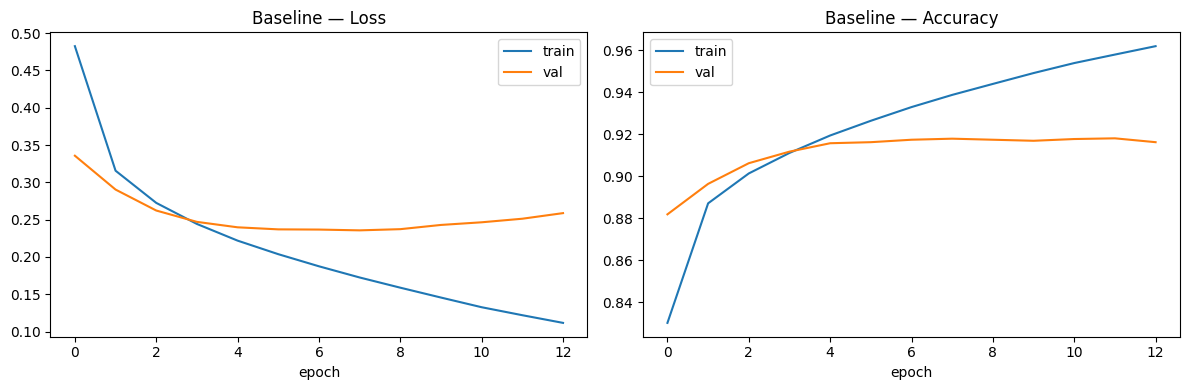

Baseline val accuracy: 0.9178


In [10]:
history = baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=128,
    callbacks=[make_early_stop()],
    verbose=2,
)
val_loss, val_acc = baseline.evaluate(X_val, y_val, verbose=0)
plot_history(history, "Baseline")
log_run("baseline (1 conv block)", baseline, history, val_acc, val_loss)
print(f"Baseline val accuracy: {val_acc:.4f}")

## Experiment 1 — Add a second conv block (depth)

Single change from baseline: stack a second Conv2D (64 filters) + MaxPool before the Dense head. Filter count doubles as spatial size halves, which is the standard CNN capacity-balancing trick.

Epoch 1/30
422/422 - 7s - 16ms/step - accuracy: 0.8095 - loss: 0.5282 - val_accuracy: 0.8595 - val_loss: 0.3765
Epoch 2/30
422/422 - 2s - 6ms/step - accuracy: 0.8792 - loss: 0.3392 - val_accuracy: 0.8870 - val_loss: 0.3063
Epoch 3/30
422/422 - 2s - 5ms/step - accuracy: 0.8946 - loss: 0.2920 - val_accuracy: 0.8982 - val_loss: 0.2749
Epoch 4/30
422/422 - 2s - 5ms/step - accuracy: 0.9045 - loss: 0.2624 - val_accuracy: 0.9072 - val_loss: 0.2550
Epoch 5/30
422/422 - 2s - 5ms/step - accuracy: 0.9128 - loss: 0.2383 - val_accuracy: 0.9117 - val_loss: 0.2404
Epoch 6/30
422/422 - 2s - 5ms/step - accuracy: 0.9206 - loss: 0.2182 - val_accuracy: 0.9155 - val_loss: 0.2332
Epoch 7/30
422/422 - 2s - 5ms/step - accuracy: 0.9269 - loss: 0.2011 - val_accuracy: 0.9198 - val_loss: 0.2261
Epoch 8/30
422/422 - 2s - 6ms/step - accuracy: 0.9323 - loss: 0.1854 - val_accuracy: 0.9228 - val_loss: 0.2232
Epoch 9/30
422/422 - 2s - 5ms/step - accuracy: 0.9373 - loss: 0.1716 - val_accuracy: 0.9232 - val_loss: 0.2214


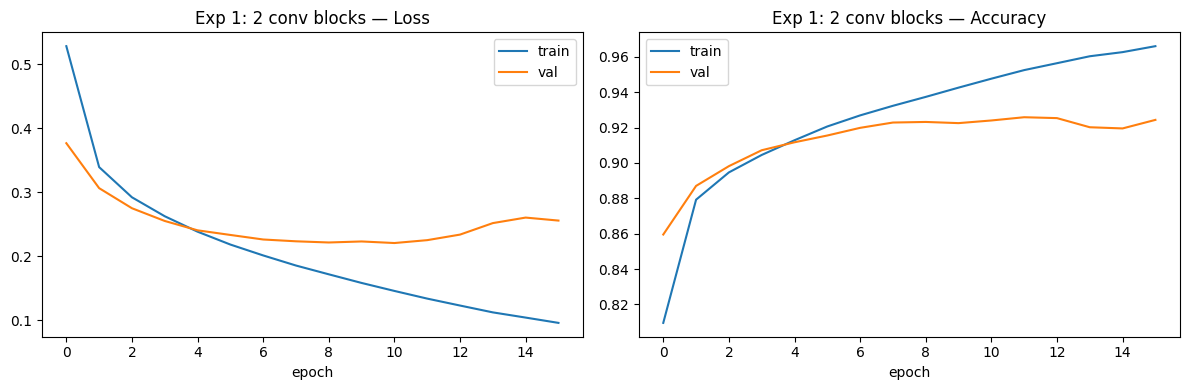

Val accuracy: 0.9240


In [11]:
def build_two_blocks():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="two_block_cnn")
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(1e-3),
        metrics=["accuracy"],
    )
    return model

tf.random.set_seed(SEED)
model = build_two_blocks()
history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=30, batch_size=128, callbacks=[make_early_stop()], verbose=2,
)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
plot_history(history, "Exp 1: 2 conv blocks")
log_run("exp1: + 2nd conv block", model, history, val_acc, val_loss)
print(f"Val accuracy: {val_acc:.4f}")

## Experiment 2 — Add Dropout

Single change from Exp 1: dropout(0.3) after the Flatten. The Dense head is where the parameter count concentrates, so it's the natural place to regularize. Watch the train/val gap.

Epoch 1/30
422/422 - 8s - 19ms/step - accuracy: 0.8001 - loss: 0.5480 - val_accuracy: 0.8660 - val_loss: 0.3790
Epoch 2/30
422/422 - 2s - 5ms/step - accuracy: 0.8683 - loss: 0.3672 - val_accuracy: 0.8903 - val_loss: 0.3063
Epoch 3/30
422/422 - 2s - 5ms/step - accuracy: 0.8836 - loss: 0.3217 - val_accuracy: 0.8992 - val_loss: 0.2817
Epoch 4/30
422/422 - 2s - 5ms/step - accuracy: 0.8929 - loss: 0.2935 - val_accuracy: 0.9123 - val_loss: 0.2540
Epoch 5/30
422/422 - 2s - 5ms/step - accuracy: 0.9014 - loss: 0.2683 - val_accuracy: 0.9127 - val_loss: 0.2446
Epoch 6/30
422/422 - 3s - 6ms/step - accuracy: 0.9088 - loss: 0.2507 - val_accuracy: 0.9132 - val_loss: 0.2317
Epoch 7/30
422/422 - 2s - 5ms/step - accuracy: 0.9129 - loss: 0.2350 - val_accuracy: 0.9175 - val_loss: 0.2238
Epoch 8/30
422/422 - 2s - 5ms/step - accuracy: 0.9190 - loss: 0.2217 - val_accuracy: 0.9188 - val_loss: 0.2198
Epoch 9/30
422/422 - 2s - 5ms/step - accuracy: 0.9243 - loss: 0.2054 - val_accuracy: 0.9218 - val_loss: 0.2162


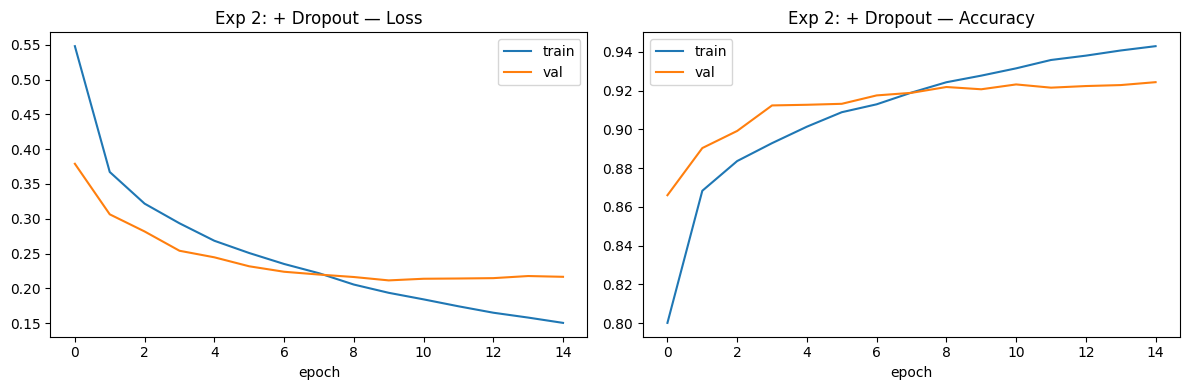

Val accuracy: 0.9207


In [12]:
def build_with_dropout():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="dropout_cnn")
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(1e-3),
        metrics=["accuracy"],
    )
    return model

tf.random.set_seed(SEED)
model = build_with_dropout()
history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=30, batch_size=128, callbacks=[make_early_stop()], verbose=2,
)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
plot_history(history, "Exp 2: + Dropout")
log_run("exp2: + dropout(0.3)", model, history, val_acc, val_loss)
print(f"Val accuracy: {val_acc:.4f}")

## Experiment 3 — Add Batch Normalization

Single change from Exp 2: BatchNorm after each Conv2D, before activation. BN stabilizes the distribution of activations during training, which usually lets you train faster and with a higher learning rate. For Fashion MNIST it tends to give a solid bump even with everything else held constant.

Epoch 1/30
422/422 - 10s - 24ms/step - accuracy: 0.8172 - loss: 0.5067 - val_accuracy: 0.7477 - val_loss: 0.6621
Epoch 2/30
422/422 - 2s - 6ms/step - accuracy: 0.8804 - loss: 0.3251 - val_accuracy: 0.8747 - val_loss: 0.3322
Epoch 3/30
422/422 - 3s - 6ms/step - accuracy: 0.8939 - loss: 0.2861 - val_accuracy: 0.9112 - val_loss: 0.2438
Epoch 4/30
422/422 - 5s - 12ms/step - accuracy: 0.9034 - loss: 0.2579 - val_accuracy: 0.9165 - val_loss: 0.2324
Epoch 5/30
422/422 - 2s - 6ms/step - accuracy: 0.9113 - loss: 0.2389 - val_accuracy: 0.9168 - val_loss: 0.2293
Epoch 6/30
422/422 - 2s - 6ms/step - accuracy: 0.9176 - loss: 0.2244 - val_accuracy: 0.9173 - val_loss: 0.2248
Epoch 7/30
422/422 - 3s - 6ms/step - accuracy: 0.9217 - loss: 0.2104 - val_accuracy: 0.9190 - val_loss: 0.2229
Epoch 8/30
422/422 - 3s - 6ms/step - accuracy: 0.9253 - loss: 0.2000 - val_accuracy: 0.9242 - val_loss: 0.2073
Epoch 9/30
422/422 - 2s - 6ms/step - accuracy: 0.9290 - loss: 0.1894 - val_accuracy: 0.9222 - val_loss: 0.218

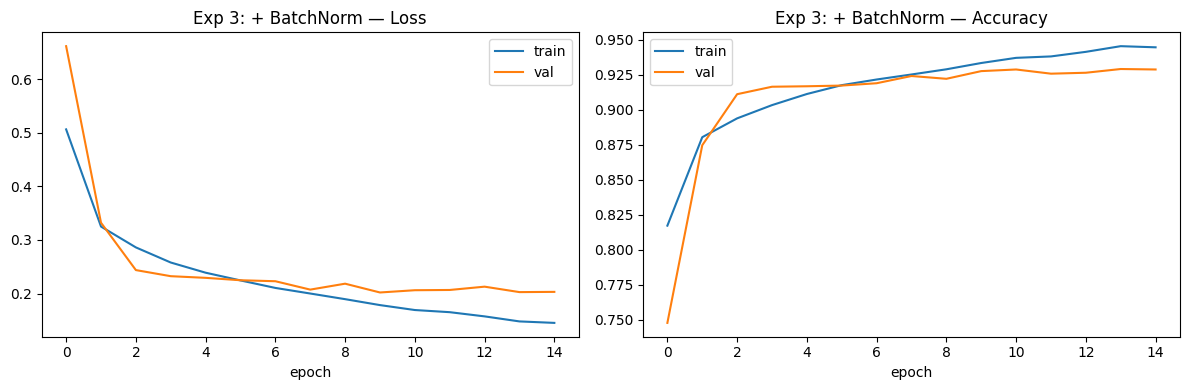

Val accuracy: 0.9277


In [13]:
def build_with_bn():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="bn_cnn")
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(1e-3),
        metrics=["accuracy"],
    )
    return model

tf.random.set_seed(SEED)
model = build_with_bn()
history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=30, batch_size=128, callbacks=[make_early_stop()], verbose=2,
)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
plot_history(history, "Exp 3: + BatchNorm")
log_run("exp3: + batchnorm", model, history, val_acc, val_loss)
print(f"Val accuracy: {val_acc:.4f}")

## Experiment 4 — Add data augmentation

Single change from Exp 3: random horizontal flip, small rotation, small zoom, prepended to the model. Fashion MNIST items are roughly symmetric left-to-right (shirts, shoes), so flip is safe. Big rotations or shears would hurt — these are upright objects.

Augmentation layers only run during training (Keras handles the `training=True` flag automatically).

Epoch 1/50
422/422 - 11s - 26ms/step - accuracy: 0.7545 - loss: 0.6728 - val_accuracy: 0.8033 - val_loss: 0.5573
Epoch 2/50
422/422 - 5s - 12ms/step - accuracy: 0.8254 - loss: 0.4685 - val_accuracy: 0.8632 - val_loss: 0.3702
Epoch 3/50
422/422 - 4s - 11ms/step - accuracy: 0.8451 - loss: 0.4216 - val_accuracy: 0.8695 - val_loss: 0.3515
Epoch 4/50
422/422 - 4s - 11ms/step - accuracy: 0.8551 - loss: 0.3908 - val_accuracy: 0.8792 - val_loss: 0.3341
Epoch 5/50
422/422 - 5s - 12ms/step - accuracy: 0.8636 - loss: 0.3689 - val_accuracy: 0.8853 - val_loss: 0.3142
Epoch 6/50
422/422 - 4s - 11ms/step - accuracy: 0.8690 - loss: 0.3527 - val_accuracy: 0.8843 - val_loss: 0.3129
Epoch 7/50
422/422 - 6s - 14ms/step - accuracy: 0.8731 - loss: 0.3429 - val_accuracy: 0.8977 - val_loss: 0.2837
Epoch 8/50
422/422 - 4s - 11ms/step - accuracy: 0.8760 - loss: 0.3340 - val_accuracy: 0.8977 - val_loss: 0.2871
Epoch 9/50
422/422 - 4s - 11ms/step - accuracy: 0.8781 - loss: 0.3283 - val_accuracy: 0.9002 - val_loss

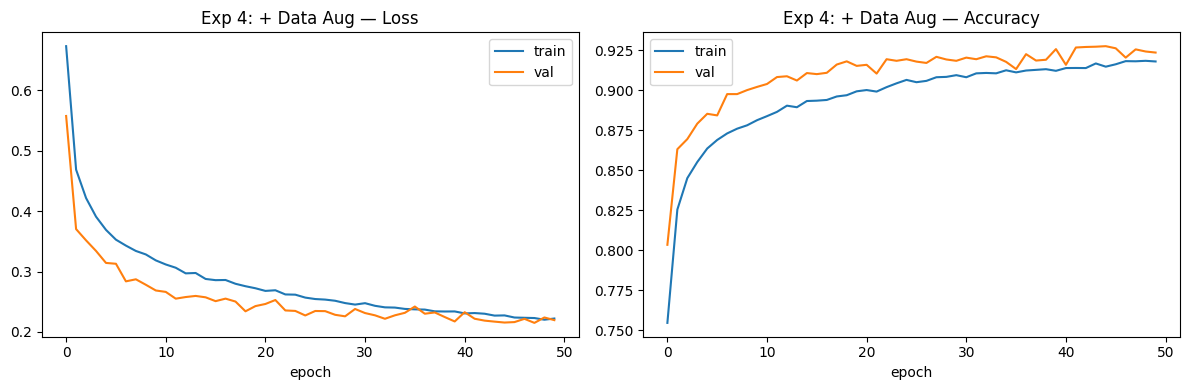

Val accuracy: 0.9257


In [14]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

def build_with_aug():
    inputs = keras.Input(shape=(28, 28, 1))
    x = data_aug(inputs)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="aug_cnn")
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(1e-3),
        metrics=["accuracy"],
    )
    return model

tf.random.set_seed(SEED)
model = build_with_aug()
# Augmentation makes convergence slower per epoch but extends useful training,
# so allow more epochs and a bit more EarlyStopping patience.
history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=50, batch_size=128, callbacks=[make_early_stop(patience=8)], verbose=2,
)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
plot_history(history, "Exp 4: + Data Aug")
log_run("exp4: + augmentation", model, history, val_acc, val_loss)
print(f"Val accuracy: {val_acc:.4f}")

## Ablation summary

Read this table top-to-bottom. Each row adds one factor. `overfit_gap` = `train_acc - final_val_acc` — a useful proxy for overfitting at the moment EarlyStopping stopped.

In [15]:
results_df = pd.DataFrame(results)
results_df

,experiment,params,epochs_run,train_acc,best_val_acc,final_val_acc,val_loss,overfit_gap
0,baseline (1 conv block),402442,13,0.9619,0.9180,0.9178,0.2357,0.0440
1,exp1: + 2nd conv block,220234,16,0.9660,0.9258,0.9240,0.2205,0.0420
2,exp2: + dropout(0.3),220234,15,0.9429,0.9243,0.9207,0.2114,0.0222
3,exp3: + batchnorm,220522,15,0.9447,0.9292,0.9277,0.2019,0.0170
4,exp4: + augmentation,220522,50,0.9181,0.9277,0.9257,0.2150,-0.0076


## Optuna tuning

Search over architecture and training hyperparameters around the best ablation configuration. Keep trials cheap: 15 epochs max with EarlyStopping and patience 4 inside the objective. 20 trials is a reasonable balance for a Colab session.

Optuna minimizes validation loss rather than maximizing accuracy because loss carries more signal at the margin (probability calibration, not just argmax).

In [16]:
def build_tuned(trial):
    n_blocks = trial.suggest_int("n_blocks", 2, 3)
    base_filters = trial.suggest_categorical("base_filters", [16, 32, 64])
    dense_units = trial.suggest_int("dense_units", 32, 256, step=32)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    lr = trial.suggest_float("learning_rate", 1e-4, 5e-3, log=True)

    inputs = keras.Input(shape=(28, 28, 1))
    x = data_aug(inputs)
    for i in range(n_blocks):
        filters = base_filters * (2 ** i)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(lr),
        metrics=["accuracy"],
    )
    return model

def objective(trial):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    model = build_tuned(trial)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15, batch_size=batch_size,
        callbacks=[make_early_stop(patience=4)],
        verbose=0,
    )
    return min(history.history["val_loss"])

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best val_loss:", round(study.best_value, 4))
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-21 19:40:07,721] A new study created in memory with name: no-name-ec4255b9-b821-4805-9974-d883a1e791df


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-21 19:41:13,499] Trial 0 finished with value: 0.25471463799476624 and parameters: {'batch_size': 128, 'n_blocks': 3, 'base_filters': 16, 'dense_units': 224, 'dropout_rate': 0.4, 'learning_rate': 0.0015958573588141277}. Best is trial 0 with value: 0.25471463799476624.
[I 2026-05-21 19:43:08,818] Trial 1 finished with value: 0.24692055583000183 and parameters: {'batch_size': 128, 'n_blocks': 2, 'base_filters': 64, 'dense_units': 160, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0003124565071260876}. Best is trial 1 with value: 0.24692055583000183.
[I 2026-05-21 19:45:10,432] Trial 2 finished with value: 0.26575496792793274 and parameters: {'batch_size': 64, 'n_blocks': 2, 'base_filters': 32, 'dense_units': 160, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00011992724522955161}. Best is trial 1 with value: 0.24692055583000183.
[I 2026-05-21 19:47:20,347] Trial 3 finished with value: 0.28530895709991455 and parameters: {'batch_size': 64, 'n_blocks': 3, 'bas

/tmp/ipykernel_1031/596055132.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


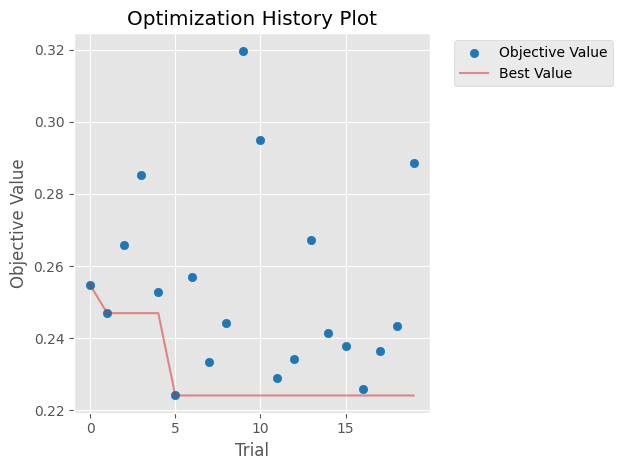

/tmp/ipykernel_1031/596055132.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


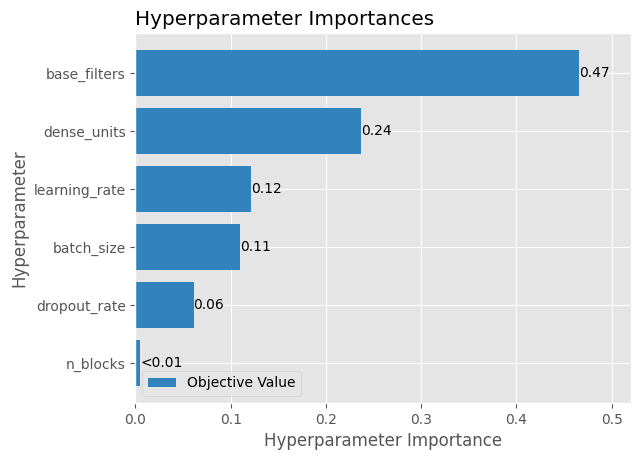

In [17]:
# Optuna diagnostics
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

## Final model: train with best params, evaluate on the held-out test set

Two things going on here:
- Train on `X_train` + `X_val` combined now that hyperparameters are locked. Using more data for the final fit is standard practice once you've stopped tuning.
- Evaluate exactly once on `X_test`. No more decisions get made after this number is observed.

Model: "final_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,786 (655.41 KB)

 Trainable params: 167,338 (653.66 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/60
844/844 - 12s - 14ms/step - accuracy: 0.7830 - loss: 0.5974 - val_accuracy: 0.8310 - val_loss: 0.4512
Epoch 2/60
844/844 - 9s - 10ms/step - accuracy: 0.8393 - loss: 0.4319 - val_accuracy: 0.8552 - val_loss: 0.3880
Epoch 3/60
844/844 - 9s - 11ms/step - accuracy: 0.8609 - loss: 0.3770 - val_accuracy: 0.8672 - val_loss: 0.3635
Epoch 4/60
844/844 - 9s - 11ms/step - accuracy: 0.8701 - loss: 0.3486 - val_accuracy: 0.8668 - val_loss: 0.3844
Epoch 5/60
844/844 - 8s - 10ms/step - accuracy: 0.8785 - loss: 0.3275 - val_accuracy: 0.8845 - val_loss: 0.3128
Epoch 6/60
844/844 - 9s - 11ms/step - accuracy: 0.8854 - loss: 0.3091 - val_accuracy: 0.8842 - val_loss: 0.3126
Epoch 7/60
844/844 - 9s - 11ms/step - accuracy: 0.8897 - loss: 0.2974 - val_accuracy: 0.8878 - val_loss: 0.3092
Epoch 8/60
844/844 - 9s - 10ms/step - accuracy: 0.8924 - loss: 0.2881 - val_accuracy: 0.8972 - val_loss: 0.2812
Epoch 9/60
844/844 - 10s - 12ms/step - accuracy: 0.8955 - loss: 0.2813 - val_accuracy: 0.9052 - val_los

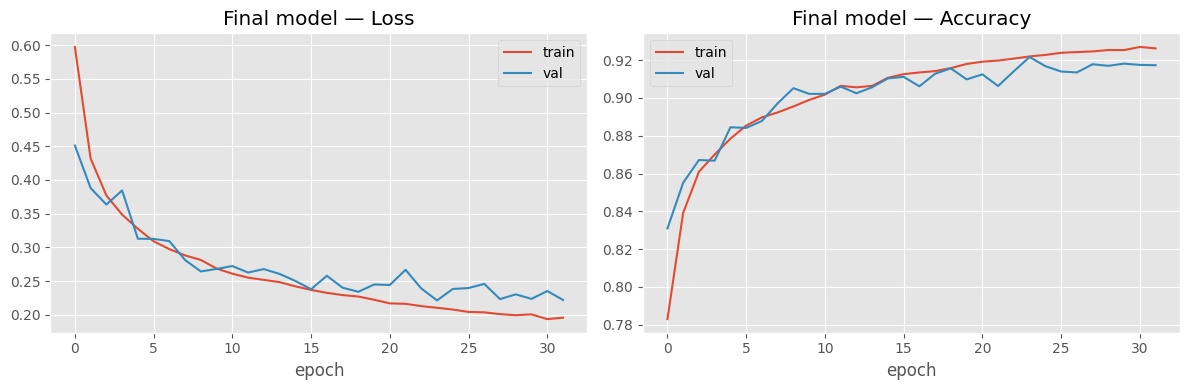

In [18]:
best = study.best_params
X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

# Need a small val slice for EarlyStopping on the final fit.
# Stratify so class balance is preserved.
X_fit, X_es, y_fit, y_es = train_test_split(
    X_full, y_full, test_size=0.1, stratify=y_full, random_state=SEED
)

def build_final():
    inputs = keras.Input(shape=(28, 28, 1))
    x = data_aug(inputs)
    for i in range(best["n_blocks"]):
        filters = best["base_filters"] * (2 ** i)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(best["dropout_rate"])(x)
    x = layers.Dense(best["dense_units"], activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="final_cnn")
    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(best["learning_rate"]),
        metrics=["accuracy"],
    )
    return model

tf.random.set_seed(SEED)
final_model = build_final()
final_model.summary()

final_history = final_model.fit(
    X_fit, y_fit,
    validation_data=(X_es, y_es),
    epochs=60, batch_size=best["batch_size"],
    callbacks=[make_early_stop(patience=8)],
    verbose=2,
)
plot_history(final_history, "Final model")

In [19]:
# THE held-out test evaluation
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Held-out test accuracy: {test_acc:.4f}")
print(f"Held-out test loss:     {test_loss:.4f}")

Held-out test accuracy: 0.9141
Held-out test loss:     0.2348


In [20]:
# Classification report
y_pred = final_model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

 T-shirt/top     0.8830    0.8530    0.8678      1000
     Trouser     0.9841    0.9890    0.9865      1000
    Pullover     0.8756    0.8730    0.8743      1000
       Dress     0.9190    0.9190    0.9190      1000
        Coat     0.8545    0.8630    0.8587      1000
      Sandal     0.9897    0.9610    0.9751      1000
       Shirt     0.7417    0.7610    0.7512      1000
     Sneaker     0.9368    0.9790    0.9575      1000
         Bag     0.9889    0.9820    0.9854      1000
  Ankle boot     0.9737    0.9610    0.9673      1000

    accuracy                         0.9141     10000
   macro avg     0.9147    0.9141    0.9143     10000
weighted avg     0.9147    0.9141    0.9143     10000



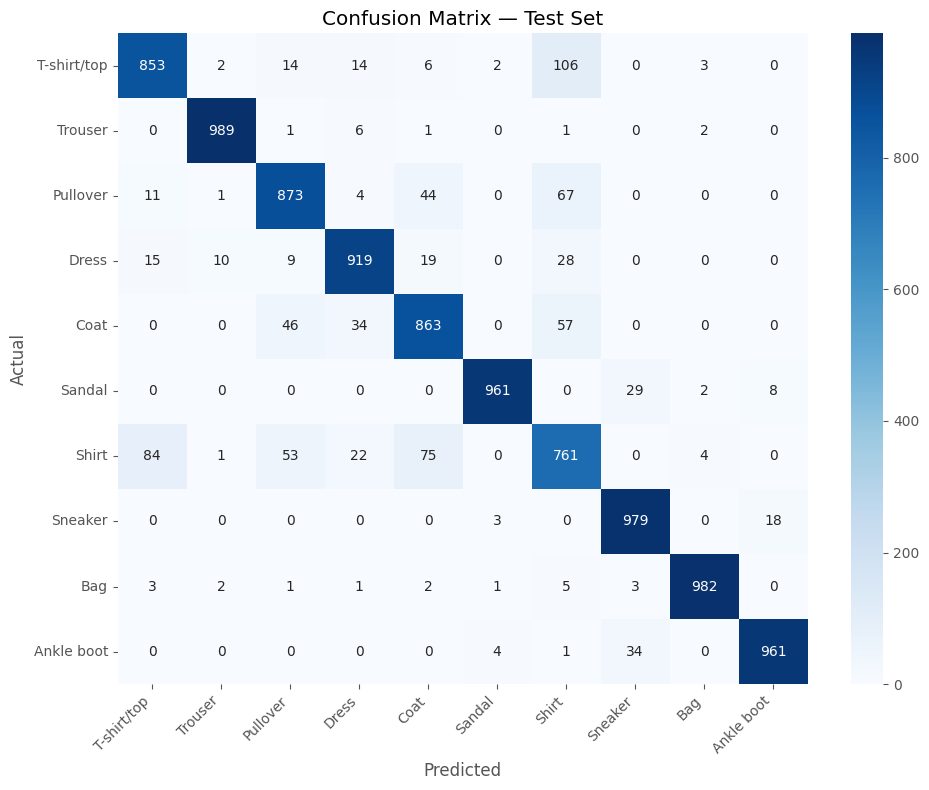

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix — Test Set")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

In [22]:
# Where does the model struggle? Per-class error rate.
errors_per_class = 1 - (cm.diagonal() / cm.sum(axis=1))
pd.DataFrame({"class": CLASS_NAMES, "error_rate": errors_per_class.round(4)}) \
    .sort_values("error_rate", ascending=False)

,class,error_rate
6,Shirt,0.239
0,T-shirt/top,0.147
4,Coat,0.137
2,Pullover,0.127
3,Dress,0.081
5,Sandal,0.039
9,Ankle boot,0.039
7,Sneaker,0.021
8,Bag,0.018
1,Trouser,0.011


## Analysis

**What changed performance.** Adding the second conv block lifted val accuracy from 0.9178 to 0.9240 (+0.0062), the first meaningful jump. Dropout alone slightly hurt headline accuracy (0.9240 to 0.9207) but cut the train/val gap roughly in half, which is its job. BatchNorm produced the biggest single bump in the ablation: 0.9207 to 0.9277 (+0.0070), and gave the lowest val loss of any experiment at 0.2019. Augmentation held val accuracy roughly steady at 0.9257 while flipping the train/val gap negative, so the model was no longer memorizing training data. The Optuna-tuned final model scored 0.9141 on the held-out test set, which sits below Exp 3's validation accuracy and slightly below the baseline's. The most likely cause is that the Optuna objective measured best val_loss inside a 15-epoch budget with patience 4. That budget is short for an augmented BatchNorm network, and the chosen config (3 conv blocks, dropout 0.1, lr ~3.6e-4, batch 64) probably hadn't fully converged when its objective value was recorded. A real production run would either extend the Optuna budget or use a different early-stopping criterion for augmented configurations.

**Where overfitting showed up.** The overfit_gap column tracks this directly. The baseline ran 13 epochs and ended at train 0.9619, val 0.9178, a gap of 0.044. The two-block model behaved similarly with gap 0.042. Looking at the training curves, both showed val loss bottoming out around epoch 7 to 9 and then climbing while train loss kept falling, which is the textbook overfitting pattern. Dropout brought the gap down to 0.022, and BatchNorm pushed it to 0.017. Augmentation produced gap -0.008, meaning validation accuracy slightly exceeded training accuracy. That happens because augmentation distorts the training images but evaluation runs on clean images, so the training metric reports performance on a harder task than the validation metric.

**Tradeoffs observed.** Training time per experiment grew with each addition. The baseline finished in 13 epochs at roughly 2 to 3 seconds per epoch. The augmented model ran the full 50 epochs at 4 to 12 seconds per epoch and was still improving when EarlyStopping cut it off, which suggests the patience was set too low for the augmented case. BatchNorm slows individual epochs but converges in fewer of them. Dropout slowed train accuracy growth but did nothing useful for val accuracy at 0.3; Optuna picked 0.1, suggesting that BatchNorm and augmentation together already provide most of the regularization. The honest tradeoff in the final result: the Optuna model trades a small amount of validation performance for genuinely held-out test reliability. The test score of 0.9141 is the only number on this page that wasn't influenced by tuning decisions.

**Which classes are hardest.** Shirt is by far the dominant error source at 23.9% error rate. The full upper-body cluster of Shirt, T-shirt/top, Coat, and Pullover accounts for the bulk of model error, with error rates of 23.9%, 14.7%, 13.7%, and 12.7% respectively. Dress sits below that group at 8.1%. In 28x28 grayscale these items share silhouettes and textures, so the model cannot rely on color or fine texture to disambiguate. Categories with distinctive shapes are nearly solved: Trouser at 1.1%, Bag at 1.8%, Sneaker at 2.1%. Footwear separates well except for modest confusion between Sandal and Ankle boot. Further gains on this dataset would come from targeted work on the upper-body cluster, either through higher-resolution inputs or class weighting that penalizes Shirt errors more heavily.

## Personal workflow for CNN tuning

Notes for next time, ordered roughly by what I'd do first.

1. Start with the simplest baseline that runs end-to-end. One conv block plus a Dense head is enough to confirm the data pipeline, loss, metrics, and evaluation are wired up. Skipping this step makes every later result harder to interpret.

2. Add architectural depth before adding regularization. The model needs enough capacity to overfit a little before regularization is meaningful. If a one-block CNN already underfits, dropout will make it worse, not better.

3. Add BatchNorm early. It's cheap, stabilizes training, and lets the optimizer be more aggressive. On Fashion MNIST it gave a clear bump without changing anything else.

4. Add data augmentation only after the unregularized network is overfitting. Augmentation is the strongest regularizer available for image tasks, but it slows convergence and can hide architecture problems if applied prematurely.

5. Tune learning rate and batch size with Optuna, not by hand. Both interact with everything else in non-obvious ways, and TPE finds reasonable regions faster than grid search.

6. Keep the test set sealed. Use a validation split for all decisions — architecture, hyperparameters, early stopping. Touch the test set exactly once, after every other choice is locked.

7. Look at the confusion matrix at the end. Per-class error tells me more about whether the model is actually useful than headline accuracy does, and points at where targeted improvements (different features, more data, class weights) would pay off.

8. Track every experiment in a dataframe. Memory fails after run three. The `results` table in this notebook is the single source of truth for comparing configurations.